# **Proyecto Automatidata**  
**Curso 4 - Análisis de regresión: simplificar relaciones complejas de datos**


La firma de consultoría de datos Automatidata te ha contratado recientemente como el miembro más nuevo de su equipo de análisis de datos. Su cliente más reciente, la Comisión de Taxis y Limusinas de la Ciudad de Nueva York (New York City TLC), quiere que el equipo de Automatidata construya un modelo de regresión lineal múltiple para predecir las tarifas de taxi usando datos existentes que fueron recopilados durante el transcurso de un año. El equipo está cada vez más cerca de completar el proyecto, habiendo terminado un plan de acción inicial, trabajo inicial de codificación en Python, EDA y pruebas A/B.

El equipo de Automatidata ha revisado los resultados de las pruebas A/B. Ahora es momento de trabajar en predecir los montos de las tarifas de taxi. Has impresionado a tus colegas de Automatidata con tu trabajo duro y atención al detalle. El equipo de datos cree que estás listo para construir el modelo de regresión y actualizar al cliente New York City TLC sobre tu progreso.

Se estructuró y preparó un cuaderno para ayudarte en este proyecto. Por favor, completa las siguientes preguntas.


# Curso 4 Proyecto de fin de curso: Construir un modelo de regresión lineal múltiple

En esta actividad, construirás un modelo de regresión lineal múltiple. Como has aprendido, la regresión lineal múltiple te ayuda a estimar la relación lineal entre una variable dependiente continua y dos o más variables independientes. Para los profesionales de ciencia de datos, esta es una habilidad útil porque te permite considerar más de una variable en comparación con la variable que estás midiendo. Esto abre la puerta a realizar análisis mucho más exhaustivos y flexibles.

Completar esta actividad te ayudará a practicar la planificación y construcción de un modelo de regresión lineal múltiple basado en una necesidad empresarial específica. La estructura de esta actividad está diseñada para emular las propuestas que probablemente te asignarán en tu carrera como profesional de datos. Completar esta actividad te ayudará a prepararte para esos momentos profesionales.
<br/>

**El propósito** de este proyecto es demostrar conocimientos de EDA y un modelo de regresión lineal múltiple

**El objetivo** es construir un modelo de regresión lineal múltiple y evaluar el modelo
<br/>
*Esta actividad tiene tres partes:*

**Parte 1:** EDA y Verificación de Suposiciones del Modelo
* ¿Cuáles son algunos propósitos del EDA antes de construir un modelo de regresión lineal múltiple?

**Parte 2:** Construcción y evaluación del modelo
* ¿Qué recursos encuentras que utilizas mientras completas esta etapa?

**Parte 3:** Interpretación de los resultados del modelo

* ¿Qué ideas clave surgieron de tu(s) modelo(s)?

* ¿Qué recomendaciones empresariales propones basadas en los modelos construidos?

Sigue las instrucciones y responde las preguntas a continuación para completar la actividad. Luego, completarás un Resumen Ejecutivo usando las preguntas listadas en el Documento de Estrategia PACE.

Asegúrate de completar esta actividad antes de continuar. El siguiente ítem del curso te proporcionará un ejemplo completo para comparar con tu propio trabajo.


# Construir un modelo de regresión lineal múltiple


<img src="images/Pace.png" width="100" height="100" align=left>

# **Etapas PACE**


A lo largo de estos cuadernos de proyecto, verás referencias al marco de resolución de problemas PACE. Los siguientes componentes del cuaderno están etiquetados con la etapa respectiva de PACE: Planear, Analizar, Construir y Ejecutar.


<img src="images/Plan.png" width="100" height="100" align=left>

## PACE: **Plan**

Considere las preguntas en su Documento de Estrategia PACE para reflexionar sobre la etapa de Plan.


### Tarea 1. Importaciones y carga
Importa los paquetes que has aprendido que son necesarios para construir modelos de regresión lineal.


In [ ]:
# Imports
# Packages for numerics + dataframes
### YOUR CODE HERE ###
import pandas as pd
import numpy as np
# Packages for visualization
### YOUR CODE HERE ###
import matplotlib.pyplot as plt
import seaborn as sns
# Packages for date conversions for calculating trip durations
### YOUR CODE HERE ###
import datetime
# Packages for OLS, MLR, confusion matrix
### YOUR CODE HERE ###
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Nota:** `Pandas` se usa para cargar el conjunto de datos de NYC TLC. Como se muestra en esta celda, el conjunto de datos ha sido cargado automáticamente para ti. No necesitas descargar el archivo .csv, ni proporcionar más código, para acceder al conjunto de datos y continuar con este laboratorio. Por favor, continúa con esta actividad completando las siguientes instrucciones.


In [3]:
# Load dataset into dataframe 
df0=pd.read_csv("2017_Yellow_Taxi_Trip_Data.csv") 

<img src="images/Analyze.png" width="100" height="100" align=left>

## PACE: **Analizar**

En esta etapa, considere la siguiente pregunta cuando sea aplicable para completar su respuesta de código:

* ¿Cuáles son algunos propósitos del Análisis Exploratorio de Datos (EDA) antes de construir un modelo de regresión lineal múltiple?


==> INGRESE SU RESPUESTA AQUÍ


### Tarea 2a. Explorar datos con EDA

Analizar y descubrir datos, buscando correlaciones, datos faltantes, valores atípicos y duplicados.


Comienza con `.shape` y `.info()`.


In [4]:
# Start with `.shape` and `.info()`
### YOUR CODE HERE ###

print(df0.shape)
df0.info()

(22699, 18)
<class 'pandas.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  str    
 3   tpep_dropoff_datetime  22699 non-null  str    
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  str    
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  t

Verificar datos faltantes y duplicados usando `.isna()` y `.drop_duplicates()`.


In [5]:
# Check for missing data and duplicates using .isna() and .drop_duplicates()
### YOUR CODE HERE ###
print(df0.isna().sum())
print(df0.duplicated().sum())

Unnamed: 0               0
VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
dtype: int64
0


Use `.describe()`.


In [6]:
# Use .describe()
### YOUR CODE HERE ###
df0.describe(include="number")

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


### Tarea 2b. Convertir columnas de recogida y entrega a fecha y hora


In [7]:
# Check the format of the data
### YOUR CODE HERE ###
print("Columna                   | Tipo de Variable   ")
print("------------------------------------------------")
for col in df0.columns:
    print(f"{col:<25} | {str(df0[col].dtype):<20}|")

Columna                   | Tipo de Variable   
------------------------------------------------
Unnamed: 0                | int64               |
VendorID                  | int64               |
tpep_pickup_datetime      | str                 |
tpep_dropoff_datetime     | str                 |
passenger_count           | int64               |
trip_distance             | float64             |
RatecodeID                | int64               |
store_and_fwd_flag        | str                 |
PULocationID              | int64               |
DOLocationID              | int64               |
payment_type              | int64               |
fare_amount               | float64             |
extra                     | float64             |
mta_tax                   | float64             |
tip_amount                | float64             |
tolls_amount              | float64             |
improvement_surcharge     | float64             |
total_amount              | float64             |


In [8]:
# Convert datetime columns to datetime
### YOUR CODE HERE ###
df0["tpep_pickup_datetime"] = pd.to_datetime(df0["tpep_pickup_datetime"])
df0["tpep_dropoff_datetime"] = pd.to_datetime(df0["tpep_dropoff_datetime"])

### Tarea 2c. Crear columna de duración


Crear una nueva columna llamada `duration` que representa el número total de minutos que duró cada viaje en taxi.


In [9]:
# Create `duration` column
### YOUR CODE HERE ###
# Crear la columna `duration` en minutos
df0["duration"] = (
    df0["tpep_dropoff_datetime"] - df0["tpep_pickup_datetime"]
).dt.total_seconds() / 60

### Outliers

Llamar a `df.info()` para inspeccionar las columnas y decidir cuáles revisar para detectar valores atípicos.


In [10]:
### YOUR CODE HERE ###
df0.info()


<class 'pandas.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Unnamed: 0             22699 non-null  int64         
 1   VendorID               22699 non-null  int64         
 2   tpep_pickup_datetime   22699 non-null  datetime64[us]
 3   tpep_dropoff_datetime  22699 non-null  datetime64[us]
 4   passenger_count        22699 non-null  int64         
 5   trip_distance          22699 non-null  float64       
 6   RatecodeID             22699 non-null  int64         
 7   store_and_fwd_flag     22699 non-null  str           
 8   PULocationID           22699 non-null  int64         
 9   DOLocationID           22699 non-null  int64         
 10  payment_type           22699 non-null  int64         
 11  fare_amount            22699 non-null  float64       
 12  extra                  22699 non-null  float64       
 13  mta_tax     

Teniendo en cuenta que muchas de las características no se utilizarán para ajustar su modelo, las columnas más importantes para verificar si hay valores atípicos probablemente sean:
* `trip_distance`
* `fare_amount`
* `duration`


### Tarea 2d. Diagramas de caja

Dibuja un diagrama de caja para cada característica: `trip_distance`, `fare_amount`, `duration`.


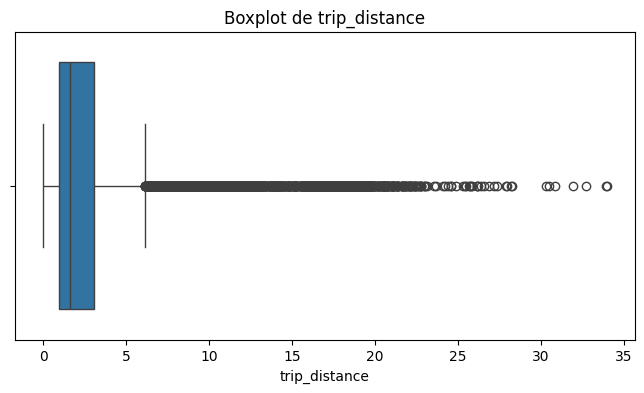

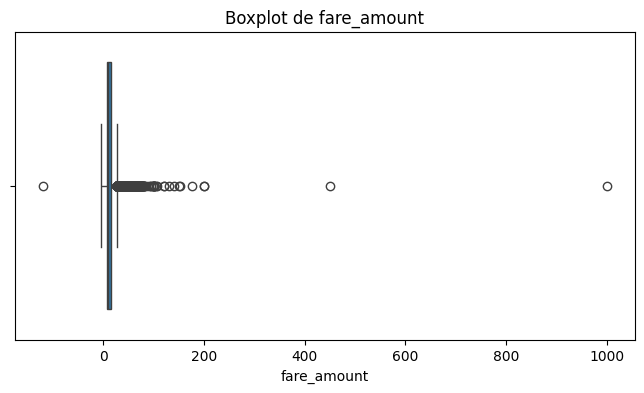

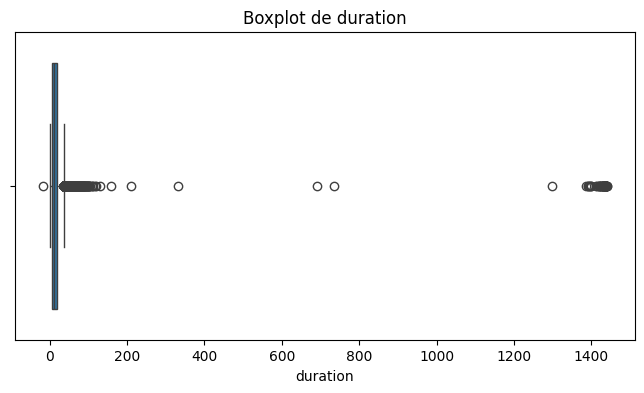

In [11]:
### YOUR CODE HERE ###
# Dibuja un diagrama de caja para cada característica: `trip_distance`, `fare_amount`, `duration`.
features = ["trip_distance", "fare_amount", "duration"]
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df0[feature])
    plt.title(f"Boxplot de {feature}")
    plt.xlabel(feature)
    plt.show()


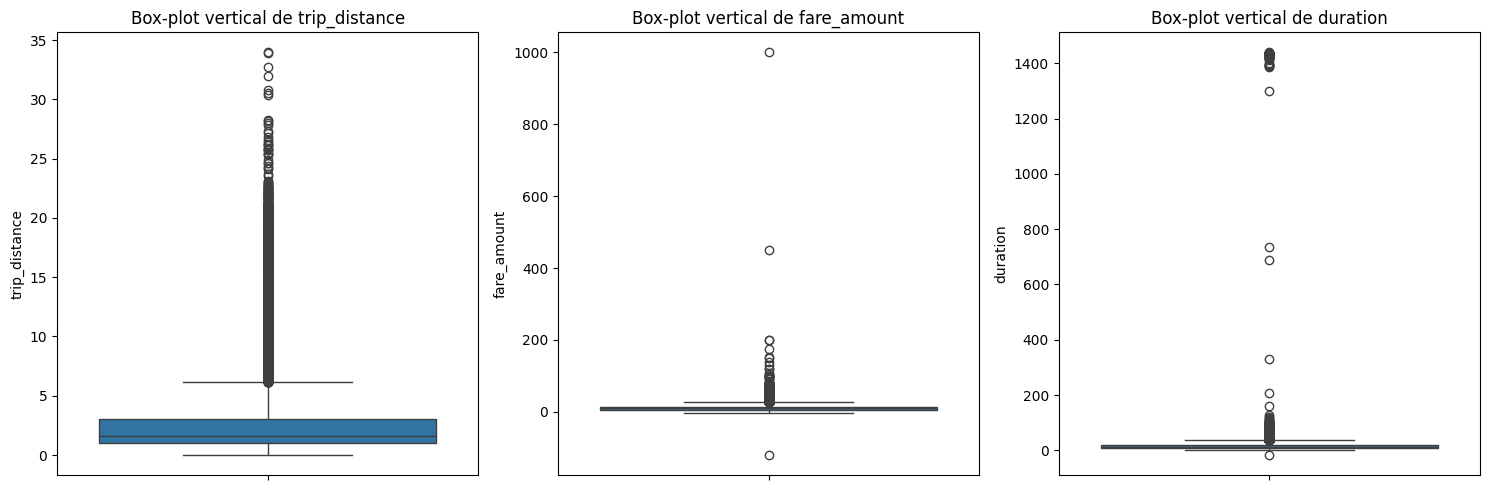

In [12]:
# -------------------------------------------------
# 1️⃣  Box‑plots verticales
# -------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
features = ["trip_distance", "fare_amount", "duration"]
plt.figure(figsize=(15, 5))               # ancho x alto (pulgadas)
for i, f in enumerate(features, 1):
    plt.subplot(1, 3, i)                  # 1 fila, 3 columnas
    sns.boxplot(y=df0[f])                 # orientación vertical → usamos 'y'
    plt.title(f"Box‑plot vertical de {f}")
    plt.ylabel(f)                         # etiqueta del eje y
plt.tight_layout()
plt.show()

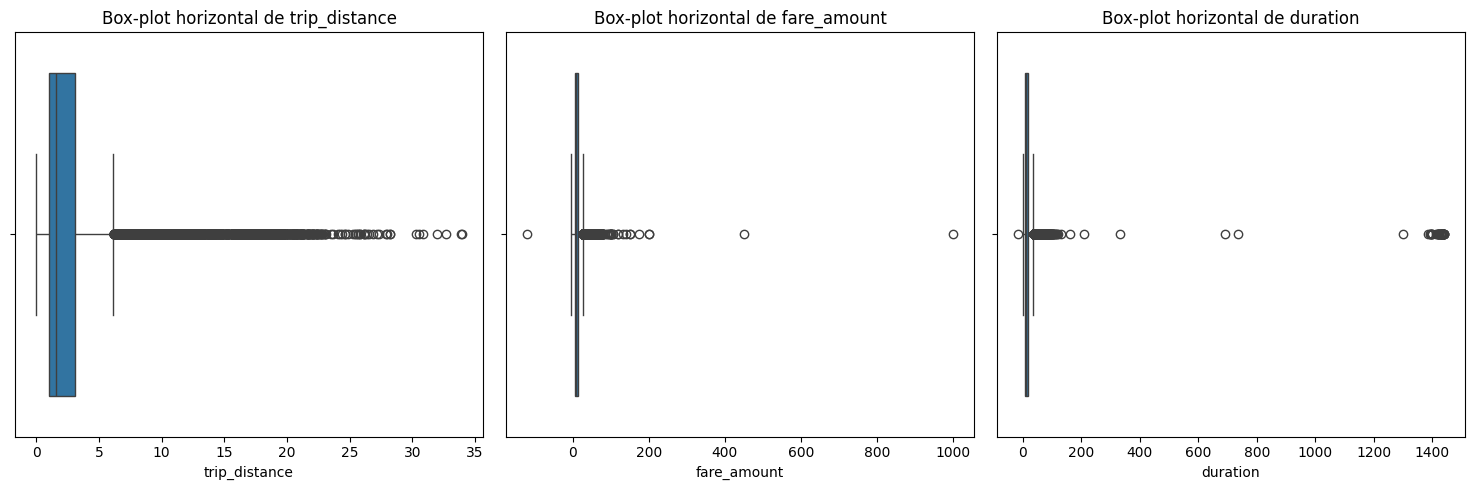

In [13]:
# -------------------------------------------------
# 2️⃣  Box‑plots horizontales
# -------------------------------------------------
plt.figure(figsize=(15, 5))
for i, f in enumerate(features, 1):
    plt.subplot(1, 3, i)                  # 1 fila, 3 columnas
    sns.boxplot(x=df0[f])                 # orientación horizontal → usamos 'x'
    plt.title(f"Box‑plot horizontal de {f}")
    plt.xlabel(f)                         # etiqueta del eje x
plt.tight_layout()
plt.show()

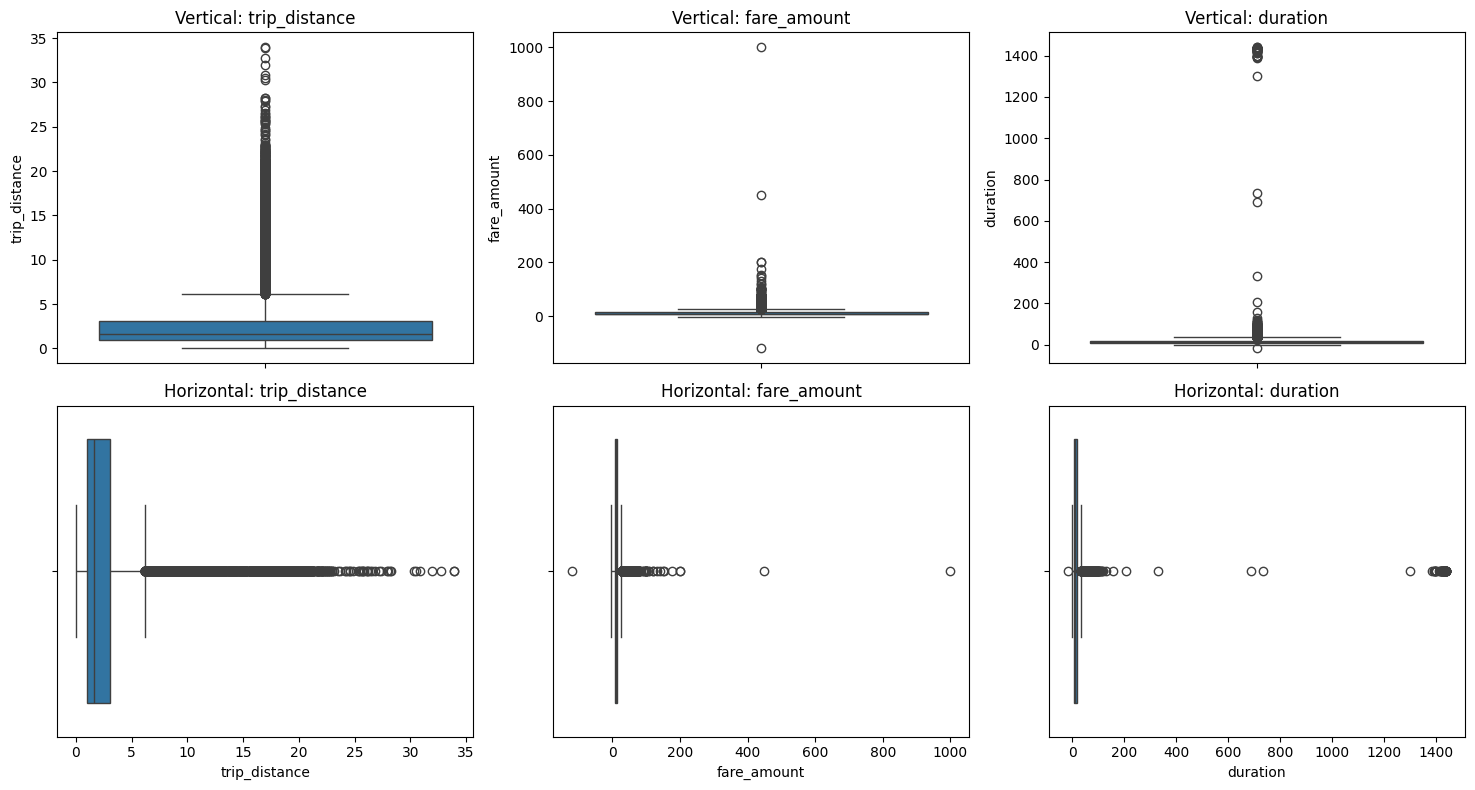

In [14]:
plt.figure(figsize=(15, 8))
# --- verticales (fila superior) ---
for i, f in enumerate(features, 1):
    plt.subplot(2, 3, i)                  # 2 filas, 3 columnas, posición i
    sns.boxplot(y=df0[f])
    plt.title(f"Vertical: {f}")
# --- horizontales (fila inferior) ---
for i, f in enumerate(features, 1):
    plt.subplot(2, 3, i + 3)              # segunda fila (i+3)
    sns.boxplot(x=df0[f])
    plt.title(f"Horizontal: {f}")
plt.tight_layout()
plt.show()

Guardar en png

```python
plt.savefig("boxplots_vertical.png", dpi=300, bbox_inches="tight")

plt.savefig("boxplots_horizontal.png", dpi=300, bbox_inches="tight")
```

#### Ventaja: Puedes comparar de un vistazo cómo cambian los outliers y la forma de la distribución según la orientación.

📖 Explicación breve (para incluir como markdown)
Box‑plot (diagrama de caja) resume la distribución de una variable numérica:

- Caja: rango intercuartílico (IQR) → del 25 % al 75 % de los datos.
- Línea dentro de la caja: mediana.
- Bigotes: valores que caen dentro de 1.5 × IQR por encima o por debajo de la caja.
- Puntos fuera de los bigotes: outliers (valores atípicos).

Cambiar la orientación (vertical ↔ horizontal) no altera la información, solo la manera de visualizarla. Usa la que resulte más clara para la audiencia o para combinar con otros gráficos.

Preguntas:  
1. ¿Qué variable(s) contiene(n) valores atípicos?  

2. ¿Son los valores en la columna `trip_distance` increíbles?  

3. ¿Qué pasa con el extremo inferior? ¿Tienen sentido las distancias, tarifas y duraciones de 0 (o valores negativos)?


==> INGRESE SU RESPUESTA AQUÍ


### Tarea 2e. Imputaciones


#### `trip_distance` outliers

Sabes por las estadísticas resumidas que hay distancias de viaje de 0. ¿Son estos reflejo de datos erróneos, o son viajes muy cortos que se redondean hacia abajo?

Para verificar, ordena los valores de la columna, elimina duplicados e inspecciona los 10 valores más bajos. ¿Son valores redondeados o valores precisos?


In [15]:
# Are trip distances of 0 bad data or very short trips rounded down?
### YOUR CODE HERE ###
#Sabes por las estadísticas resumidas que hay distancias de viaje de 0. ¿Son estos reflejo de datos erróneos, o son viajes muy cortos que se redondean hacia abajo?

# Para verificar, ordena los valores de la columna, elimina duplicados e inspecciona los 10 valores más bajos. ¿Son valores redondeados o valores precisos?

df0["trip_distance"].sort_values().drop_duplicates(inplace=True)

In [16]:
df0["trip_distance"].head(10)

0     3.34
1     1.80
2     1.00
3     3.70
4     4.37
5     2.30
6    12.83
7     2.98
8     1.20
9     1.60
Name: trip_distance, dtype: float64

Las distancias se capturan con un alto grado de precisión. Sin embargo, podría ser posible que los viajes tengan distancias de cero si un pasajero llamó a un taxi y luego cambió de opinión. Además, ¿hay suficientes valores cero en los datos para representar un problema?

Calcule la cantidad de viajes donde el `trip_distance` es cero.


In [17]:
### YOUR CODE HERE ###
df0[df0["trip_distance"] == 0]

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
128,52987734,1,2017-06-22 08:05:33,2017-06-22 08:05:40,1,0.0,3,N,231,231,2,20.0,0.0,0.0,0.00,0.0,0.3,20.30,0.116667
246,78660848,1,2017-09-18 20:50:53,2017-09-18 20:51:03,1,0.0,1,N,145,145,2,2.5,0.5,0.5,0.00,0.0,0.3,3.80,0.166667
291,83480088,1,2017-10-04 19:46:24,2017-10-04 19:46:50,1,0.0,1,N,132,132,2,2.5,1.0,0.5,0.00,0.0,0.3,4.30,0.433333
319,14024301,1,2017-02-22 04:01:44,2017-02-22 04:01:53,1,0.0,1,N,90,90,3,2.5,0.5,0.5,0.00,0.0,0.3,3.80,0.150000
424,3767951,1,2017-01-14 07:00:26,2017-01-14 07:00:53,1,0.0,1,N,208,208,1,2.5,0.0,0.5,6.70,0.0,0.3,10.00,0.450000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22190,87078850,1,2017-10-16 08:34:07,2017-10-16 08:34:10,1,0.0,1,N,132,132,3,2.5,0.0,0.5,0.00,0.0,0.3,3.30,0.050000
22325,62192517,2,2017-07-21 23:30:29,2017-07-21 23:31:12,1,0.0,5,N,163,163,1,16.8,0.0,0.0,3.42,0.0,0.3,20.52,0.716667
22383,113244949,2,2017-01-07 04:48:42,2017-01-07 04:51:03,1,0.0,5,N,55,55,2,10.0,0.0,0.0,0.00,0.0,0.3,10.30,2.350000
22566,19022898,2,2017-03-07 02:24:47,2017-03-07 02:24:50,1,0.0,1,N,264,193,1,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.050000


#### `fare_amount` outliers


In [18]:
### YOUR CODE HERE ###
df0["fare_amount"].sort_values()

12944   -120.00
11204     -4.50
20698     -4.50
17602     -4.00
14714     -4.00
          ...  
12511    175.00
15474    200.00
13861    200.01
20312    450.00
8476     999.99
Name: fare_amount, Length: 22699, dtype: float64

**Pregunta:** ¿Qué notas sobre los valores en la columna `fare_amount`?

Imputa valores menores a $0 con `0`.


In [19]:
# Impute values less than $0 with 0
### YOUR CODE HERE ###
df0.loc[df0["fare_amount"] < 0, "fare_amount"] = 0

Ahora impute el valor máximo como `Q3 + (6 * IQR)`.


In [20]:
### YOUR CODE HERE ###
def impute_outliers_iqr(df, column_list, iqr_factor):
    '''
    Impute upper-limit values in specified columns based on their interquartile range.

    Arguments:
        column_list: A list of columns to iterate over
        iqr_factor: A number representing x in the formula:
                    Q3 + (x * IQR). Used to determine maximum threshold,
                    beyond which a point is considered an outlier.

    The IQR is computed for each column in column_list and values exceeding
    the upper threshold for each column are imputed with the upper threshold value.
    '''
    for column in column_list:
        # -------------------------------------------------
        # 1️⃣  Convertir `timedelta` → minutos (float)
        # -------------------------------------------------
        if pd.api.types.is_timedelta64_dtype(df[col]):
            # Transformamos a minutos antes de cualquier comparación
            df[col] = df[col].dt.total_seconds() / 60


        # Reassign minimum to zero
        # -------------------------------------------------
        # 2️⃣  Asegurarse de que no haya valores negativos
        # -------------------------------------------------
        df[column] = df[column].clip(lower=0)

        # Calculate upper threshold
         # -------------------------------------------------
        # 3️⃣  Calcular los límites IQR
        # -------------------------------------------------
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        upper_threshold = Q3 + (iqr_factor * IQR)

        # Reassign values > threshold to threshold
        # -------------------------------------------------
        # 4️⃣  Recortar los valores superiores al umbral
        # -------------------------------------------------
        df[column] = df[column].clip(upper=upper_threshold)

        # Reassign values > threshold to threshold
      ### YOUR CODE HERE ###
    
impute_outliers_iqr(df0, 
        column_list=["trip_distance", "fare_amount", "duration"], 
        iqr_factor = 6)

#### `duration` outliers


In [21]:
# Call .describe() for duration outliers
### YOUR CODE HERE ###
# Impute a 0 for any negative values in duration
df0.loc[df0["duration"] < 0, "duration"] = 0

# Impute high outliers for duration
impute_outliers_iqr(df0, ["duration"], 6)

La columna `duration` tiene valores problemáticos tanto en los extremos inferiores como en los superiores.

* **Valores bajos:** No debe haber valores que representen tiempo negativo. Imputa todas las duraciones negativas con `0`.

* **Valores altos:** Imputa los valores altos de la misma manera que imputaste los valores atípicos en el extremo superior para las tarifas: `Q3 + (6 * IQR)`.


In [22]:
# Impute a 0 for any negative values
### YOUR CODE HERE ###
df0.loc[df0["duration"] < 0, "duration"] = 0

In [23]:
# Impute the high outliers
### YOUR CODE HERE ###
impute_outliers_iqr(df0, ["duration"], 6)

In [24]:
# Verificamos que la imputación se haya realizado correctamente
df0["duration"].describe()

count    22699.000000
mean        14.460555
std         11.947043
min          0.000000
25%          6.650000
50%         11.183333
75%         18.383333
max         88.783333
Name: duration, dtype: float64

### Tarea 3a. Ingeniería de características


#### Crear la columna `mean_distance`

Cuando se despliega, el modelo no sabrá la duración de un viaje hasta después de que ocurra el viaje, por lo que no se puede entrenar un modelo que utilice esta característica. Sin embargo, puedes usar las estadísticas de los viajes que *sí* conoces para generalizar sobre los que no conoces.

En este paso, crea una columna llamada `mean_distance` que capture la distancia media para cada grupo de viajes que comparten puntos de recogida y entrega.

Por ejemplo, si tus datos fueran:

|Viaje|Inicio|Fin|Distancia|
|--: |:---:|:-:|:-:|
| 1  | A   | B | 1  |
| 2  | C   | D | 2  |
| 3  | A   | B |1.5 |
| 4  | D   | C | 3  |

Los resultados deberían ser:
```
A -> B: 1.25 millas
C -> D: 2 millas
D -> C: 3 millas
```

Observa que C -> D no es lo mismo que D -> C. Todos los viajes que comparten un par único de puntos de inicio y fin se agrupan y promedian.

Luego, se añadirá una nueva columna `mean_distance` donde el valor en cada fila es el promedio de todos los viajes con esas ubicaciones de recogida y entrega:

|Viaje|Inicio|Fin|Distancia|mean_distance|
|--: |:---:|:-:|  :--   |:--   |
| 1  | A   | B | 1      | 1.25 |
| 2  | C   | D | 2      | 2    |
| 3  | A   | B |1.5     | 1.25 |
| 4  | D   | C | 3      | 3    |


Comienza creando una columna auxiliar llamada `pickup_dropoff`, que contiene la combinación única de los IDs de ubicación de recogida y entrega para cada fila.

Una forma de hacer esto es convertir los IDs de ubicación de recogida y entrega en cadenas y unirlos, separados por un espacio. El espacio es para asegurar que, por ejemplo, un viaje con puntos de recogida/entrega 12 y 151 se codifique de manera diferente a un viaje con puntos 121 y 51.

Entonces, la nueva columna se vería así:

|Viaje|Inicio|Fin|pickup_dropoff|
|--: |:---:|:-:|  :--         |
| 1  | A   | B | 'A B'        |
| 2  | C   | D | 'C D'        |
| 3  | A   | B | 'A B'        |
| 4  | D   | C | 'D C'        |


In [25]:
# Create `pickup_dropoff` column
# Crear columna auxiliar 'pickup_dropoff' concatenando pickup and dropoff location IDs como strings,
df0['pickup_dropoff'] = df0['PULocationID'].astype(str) + ' ' + df0['DOLocationID'].astype(str)

Ahora, use una declaración `groupby()` para agrupar cada fila por la nueva columna `pickup_dropoff`, calcular la media y capturar los valores solo en la columna `trip_distance`. Asigne los resultados a una variable llamada `grouped`.


In [26]:
### YOUR CODE HERE ###
# Convertir 'grouped' a diccionario y reasignar para contener solo el diccionario interno",
grouped = df0.groupby('pickup_dropoff')['trip_distance'].mean()
grouped

pickup_dropoff
1 1         2.433333
10 148     15.480000
100 1      15.480000
100 100     0.253333
100 107     1.180000
             ...    
97 65       0.500000
97 66       1.400000
97 80       3.840000
97 90       4.420000
97 97       1.006667
Name: trip_distance, Length: 4172, dtype: float64

In [27]:
grouped_df =  df0.groupby('pickup_dropoff')[['trip_distance']].mean()
grouped_df

,trip_distance
pickup_dropoff,
1 1,2.433333
10 148,15.480000
100 1,15.480000
100 100,0.253333
100 107,1.180000
...,...
97 65,0.500000
97 66,1.400000
97 80,3.840000


`grouped` es un objeto de la clase `DataFrame`.

1. Conviértelo a un diccionario usando el método [`to_dict()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_dict.html). Asigna los resultados a una variable llamada `grouped_dict`. Esto dará como resultado un diccionario con una clave de `trip_distance` cuyos valores son otro diccionario. Las claves del diccionario interno son puntos de recogida/entrega y sus valores son distancias medias. Esta es la información que deseas.

```
Ejemplo:
grouped_dict = {'trip_distance': {'A B': 1.25, 'C D': 2, 'D C': 3}
```

2. Reasigna el diccionario `grouped_dict` para que contenga solo el diccionario interno. En otras palabras, elimina `trip_distance` como clave, así que:

```
Ejemplo:
grouped_dict = {'A B': 1.25, 'C D': 2, 'D C': 3}
 ```


In [28]:
# 1. Convert `grouped` to a dictionary
### YOUR CODE HERE ###
grouped_dict = grouped.to_dict()
print(grouped_dict)
# 2. Reassign to only contain the inner dictionary
### YOUR CODE HERE ###


{'1 1': 2.433333333333333, '10 148': 15.480000000000002, '100 1': 15.480000000000002, '100 100': 0.25333333333333335, '100 107': 1.18, '100 113': 2.024, '100 114': 1.94, '100 12': 4.55, '100 125': 2.84, '100 13': 4.201666666666667, '100 132': 15.480000000000002, '100 137': 1.299, '100 138': 10.432857142857143, '100 140': 2.746, '100 141': 2.11, '100 142': 1.6958333333333335, '100 143': 1.5825, '100 144': 3.0066666666666664, '100 148': 4.1066666666666665, '100 151': 3.668, '100 152': 4.9, '100 158': 1.938, '100 161': 0.9813888888888889, '100 162': 1.2163636363636363, '100 163': 1.2656, '100 164': 0.841, '100 166': 5.199999999999999, '100 170': 0.8548, '100 177': 12.0, '100 181': 9.34, '100 186': 0.6404761904761904, '100 193': 4.39, '100 198': 9.01, '100 202': 5.3, '100 209': 4.43, '100 211': 2.48, '100 224': 1.9500000000000002, '100 225': 7.5, '100 229': 1.7850000000000001, '100 230': 0.72975, '100 231': 3.5216666666666665, '100 232': 3.8449999999999998, '100 233': 1.2458333333333333, '

1. Crear una columna `mean_distance` que sea una copia de la columna auxiliar `pickup_dropoff`.

2. Utilizar el método [`map()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html#pandas-series-map) en la serie `mean_distance`. Pasar `grouped_dict` como su argumento. Reasignar el resultado de nuevo a la serie `mean_distance`.
</br></br>
Cuando pasas un diccionario al método `Series.map()`, reemplazará los datos en la serie donde esos datos coincidan con las claves del diccionario. Los valores que se imputan son los valores del diccionario.

```
Ejemplo:
df['mean_distance']
```

|mean_distance |
|  :-:         |
| 'A B'        |
| 'C D'        |
| 'A B'        |
| 'D C'        |
| 'E F'        |

```
grouped_dict = {'A B': 1.25, 'C D': 2, 'D C': 3}
df['mean_distance`] = df['mean_distance'].map(grouped_dict)
df['mean_distance']
```

|mean_distance |
|  :-:         |
| 1.25         |
| 2            |
| 1.25         |
| 3            |
| NaN          |

Cuando se usa de esta manera, el método `map()` de `Series` es muy similar a `replace()`, sin embargo, tenga en cuenta que `map()` imputará `NaN` para cualquier valor en la serie que no tenga una clave correspondiente en el diccionario de mapeo, así que tenga cuidado.


In [29]:
# 1. Create a mean_distance column that is a copy of the pickup_dropoff helper column
### YOUR CODE HERE ###
df0['mean_distance'] = df0['pickup_dropoff']
# 2. Map `grouped_dict` to the `mean_distance` column
### YOUR CODE HERE ###
df0['mean_distance'] = df0['mean_distance'].map(grouped_dict)
# Confirm that it worked
### YOUR CODE HERE ###
df0[['pickup_dropoff', 'trip_distance', 'mean_distance']].head(10)

,pickup_dropoff,trip_distance,mean_distance
0,100 231,3.34,3.521667
1,186 43,1.80,3.108889
2,262 236,1.00,0.881429
3,188 97,3.70,3.700000
4,4 112,4.37,4.435000
5,161 236,2.30,2.052258
6,79 241,12.83,12.830000
7,237 114,2.98,4.022500
8,234 249,1.20,1.019259
9,239 237,1.60,1.580000


💡 ¿Cómo funciona .map()?
Recorre cada valor de la columna pickup_dropoff, lo busca como clave en grouped_dict y lo reemplaza por su valor (la distancia media). Si un valor no existe en el dict, pone NaN.

#### Crear columna `mean_duration`

Repite el proceso utilizado para crear la columna `mean_distance` para crear una columna `mean_duration`.


In [30]:
### YOUR CODE HERE ###

# Create a dictionary where keys are unique pickup_dropoffs and values are
# mean trip duration for all trips with those pickup_dropoff combos
### YOUR CODE HERE ###

# Confirm that it worked
### YOUR CODE HERE ###

# Agrupar por pickup_dropoff y calcular la duración media → DataFrame
grouped2 = df0.groupby('pickup_dropoff')[['duration']].mean()
# Crear diccionario con la clave exterior 'duration'
grouped_dict2 = grouped2.to_dict()
# Extraer solo el diccionario interno
grouped_dict2 = grouped_dict2['duration']
# Crear columna mean_duration y mapear los valores
df0['mean_duration'] = df0['pickup_dropoff']
df0['mean_duration'] = df0['mean_duration'].map(grouped_dict2)
# Confirm that it worked
df0[['pickup_dropoff', 'duration', 'mean_duration']].head(10)

,pickup_dropoff,duration,mean_duration
0,100 231,14.066667,22.847222
1,186 43,26.500000,24.470370
2,262 236,7.200000,7.250000
3,188 97,30.250000,30.250000
4,4 112,16.716667,14.616667
5,161 236,8.000000,11.855376
6,79 241,59.633333,59.633333
7,237 114,21.983333,26.437500
8,234 249,12.116667,7.873457
9,239 237,20.433333,10.541111


#### Crear columnas `day` y `month`

Crear dos nuevas columnas, `day` (nombre del día) y `month` (nombre del mes) extrayendo la información relevante de la columna `tpep_pickup_datetime`.


In [31]:
# Create 'day' col
### YOUR CODE HERE ###

# Create 'month' col
### YOUR CODE HERE ###

# Create 'day' col — nombre del día de la semana
df0['day'] = df0['tpep_pickup_datetime'].dt.day_name()
# Create 'month' col — nombre del mes
df0['month'] = df0['tpep_pickup_datetime'].dt.month_name()
df0[['tpep_pickup_datetime', 'day', 'month']].head(10)

,tpep_pickup_datetime,day,month
0,2017-03-25 08:55:43,Saturday,March
1,2017-04-11 14:53:28,Tuesday,April
2,2017-12-15 07:26:56,Friday,December
3,2017-05-07 13:17:59,Sunday,May
4,2017-04-15 23:32:20,Saturday,April
5,2017-03-25 20:34:11,Saturday,March
6,2017-05-03 19:04:09,Wednesday,May
7,2017-08-15 17:41:06,Tuesday,August
8,2017-02-04 16:17:07,Saturday,February
9,2017-11-10 15:20:29,Friday,November


#### Crear columna `rush_hour`

Define la hora pico como:
* Cualquier día de la semana (no sábado ni domingo) Y
* Ya sea de 06:00–10:00 o de 16:00–20:00

Crear una columna binaria `rush_hour` que contenga un 1 si el viaje fue durante la hora pico y un 0 si no lo fue.


In [33]:
# Create 'rush_hour' col
### YOUR CODE HERE ###

# Horas punta: AM (6-10h) y PM (16-20h) en días de semana (lunes=0 a viernes=4)
def rush_hourizer(dt):
    hour = dt.hour
    day  = dt.dayofweek  # 0=lunes, 6=domingo
    # Excluir fines de semana
    if day >= 5:
        return 0
    # Rush hour mañana: 6am-10am | tarde: 4pm-8pm
    if (6 <= hour < 10) or (16 <= hour < 20):
        return 1
    return 0

# If day is Saturday or Sunday, impute 0 in `rush_hour` column
### YOUR CODE HERE ###

In [34]:
# Apply the `rush_hourizer()` function to the new column
### YOUR CODE HERE ###
df0['rush_hour'] = df0['tpep_pickup_datetime'].apply(rush_hourizer)

In [35]:
df0.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,N,100,231,...,0.0,0.3,16.56,14.066667,100 231,3.521667,22.847222,Saturday,March,0
1,35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,1,1.80,1,N,186,43,...,0.0,0.3,20.80,26.500000,186 43,3.108889,24.470370,Tuesday,April,0
2,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,N,262,236,...,0.0,0.3,8.75,7.200000,262 236,0.881429,7.250000,Friday,December,1
3,38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,1,3.70,1,N,188,97,...,0.0,0.3,27.69,30.250000,188 97,3.700000,30.250000,Sunday,May,0
4,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,N,4,112,...,0.0,0.3,17.80,16.716667,4 112,4.435000,14.616667,Saturday,April,0



```python
# Versión vectorizada (más rápida para 22k+ filas)
hour = df0['tpep_pickup_datetime'].dt.hour
day  = df0['tpep_pickup_datetime'].dt.dayofweek  # 0=lunes, 6=domingo
df0['rush_hour'] = (
    (day < 5) &                          # Días laborables
    ((hour.between(6, 9)) |              # 6am-9:59am
     (hour.between(16, 19)))             # 4pm-7:59pm
).astype(int)
# Verificar distribución
print(df0['rush_hour'].value_counts())
print(f"\nProporción rush hour: {df0['rush_hour'].mean():.1%}")
```


### Tarea 4. Diagrama de dispersión

Crea un diagrama de dispersión para visualizar la relación entre `mean_duration` y `fare_amount`.


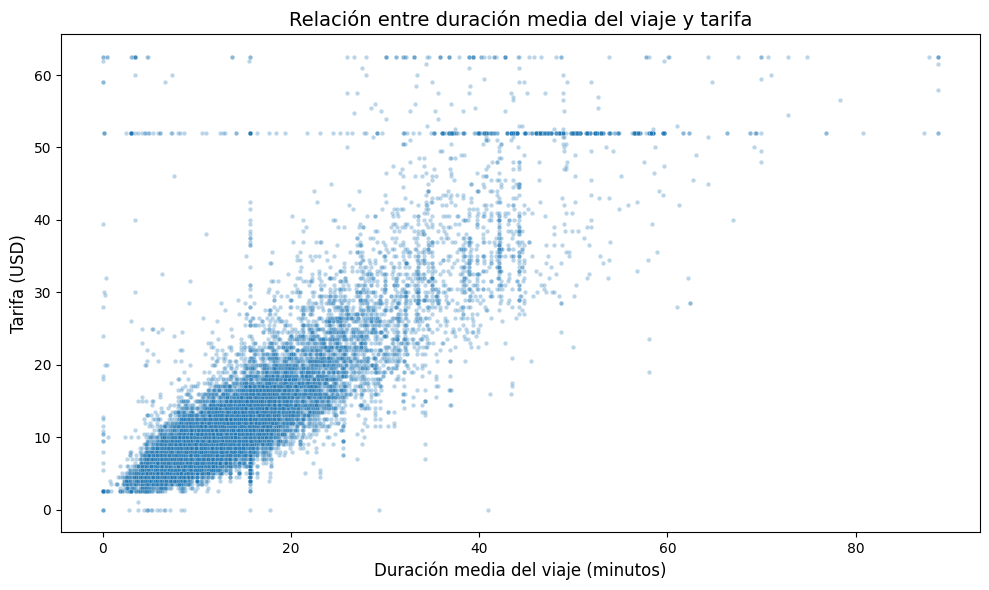

In [36]:
# Create a scatterplot to visualize the relationship between variables of interest
### YOUR CODE HERE ###
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df0, x='mean_duration', y='fare_amount',
                alpha=0.3, s=10, ax=ax)
ax.set_xlabel('Duración media del viaje (minutos)', fontsize=12)
ax.set_ylabel('Tarifa (USD)', fontsize=12)
ax.set_title('Relación entre duración media del viaje y tarifa', fontsize=14)
plt.tight_layout()
plt.show()

La variable `mean_duration` se correlaciona con la variable objetivo. Pero, ¿qué representan las líneas horizontales alrededor de los montos de tarifa de 52 dólares y 63 dólares? ¿Cuáles son los valores y cuántos hay?

Sabes lo que representa una de las líneas. 62 dólares y 50 centavos es el máximo que se imputó para los valores atípicos, por lo que todos los antiguos valores atípicos ahora tendrán montos de tarifa de \$62.50. ¿Cuál es la otra línea?

Verifica el valor de los viajes en la segunda línea horizontal en el diagrama de dispersión.


In [38]:
### YOUR CODE HERE ###
df0[df0['fare_amount'] == 52].shape

(514, 25)

Examine los primeros 30 de estos viajes.


In [39]:
# Set pandas to display all columns
### YOUR CODE HERE ###
df0[df0['fare_amount'] == 52].head(30)

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,tolls_amount,improvement_surcharge,total_amount,duration,pickup_dropoff,mean_distance,mean_duration,day,month,rush_hour
11,18600059,2,2017-03-05 19:15:30,2017-03-05 19:52:18,2,15.48,2,N,236,132,...,5.54,0.3,72.92,36.800000,236 132,15.480000,40.500000,Sunday,March,0
110,47959795,1,2017-06-03 14:24:57,2017-06-03 15:31:48,1,15.48,2,N,132,163,...,0.00,0.3,52.80,66.850000,132 163,15.480000,52.941667,Saturday,June,0
161,95729204,2,2017-11-11 20:16:16,2017-11-11 20:17:14,1,0.23,2,N,132,132,...,0.00,0.3,52.80,0.966667,132 132,1.941034,3.021839,Saturday,November,0
247,103404868,2,2017-12-06 23:37:08,2017-12-07 00:06:19,1,15.48,2,N,132,79,...,0.00,0.3,52.80,29.183333,132 79,15.480000,47.275000,Wednesday,December,0
379,80479432,2,2017-09-24 23:45:45,2017-09-25 00:15:14,1,15.48,2,N,132,234,...,5.76,0.3,73.20,29.483333,132 234,15.480000,49.833333,Sunday,September,0
388,16226157,1,2017-02-28 18:30:05,2017-02-28 19:09:55,1,15.48,2,N,132,48,...,5.54,0.3,62.84,39.833333,132 48,15.480000,58.246032,Tuesday,February,1
406,55253442,2,2017-06-05 12:51:58,2017-06-05 13:07:35,1,4.73,2,N,228,88,...,5.76,0.3,58.56,15.616667,228 88,4.730000,15.616667,Monday,June,0
449,65900029,2,2017-08-03 22:47:14,2017-08-03 23:32:41,2,15.48,2,N,132,48,...,5.76,0.3,58.56,45.450000,132 48,15.480000,58.246032,Thursday,August,0
468,80904240,2,2017-09-26 13:48:26,2017-09-26 14:31:17,1,15.48,2,N,186,132,...,5.76,0.3,58.56,42.850000,186 132,15.480000,42.920000,Tuesday,September,0
520,33706214,2,2017-04-23 21:34:48,2017-04-23 22:46:23,6,15.48,2,N,132,148,...,0.00,0.3,57.80,71.583333,132 148,15.480000,46.340476,Sunday,April,0


**Pregunta:** ¿Qué notas sobre los primeros 30 viajes?

==> INGRESA TU RESPUESTA AQUÍ


🔍 Análisis de los 30 registros
Estos son exactamente los viajes que forman la segunda línea horizontal en el scatter plot (~$52). Hay patrones muy claros:

🚨 Hallazgo principal: RatecodeID = 2 en TODOS

|Campo|	Observación |
|:---:|:------------|
|RatecodeID|	2 en los 30 registros → Tarifa especial JFK|
|trip_distance|	15.48 millas en la mayoría → distancia JFK ↔ Manhattan imputada por el IQR cap|
|PULocationID / DOLocationID|	132 aparece en casi todos → Código del aeropuerto JFK|  


Según la NYC TLC, el RatecodeID = 2 corresponde a la tarifa plana JFK ↔ Manhattan de $52.00. No importa cuánto tarde el viaje: el precio es fijo.

📌 Por eso aparece la línea horizontal

fare_amount = $52  →  fija, sin importar la duración del viaje

Eso viola la relación lineal duración → tarifa que busca el modelo. Los viajes con RatecodeID 2 son un caso especial.

🧾 Otros patrones interesantes

|Observación|Detalle|
|:---------:|:-----:|
|tolls_amount tiene dos valores|	$5.54 / $5.76 (peaje MTA) o $0 (sin peaje, distintas rutas)|
|rush_hour es 0 o 1 indistintamente|	La tarifa plana no depende del horario|
|day varía (lunes a domingo)|	La tarifa plana aplica todos los días|
|total_amount varía aunque fare_amount = $52|	Diferencia: propina + peajes|

✅ Recomendación para el modelo

Estos viajes de tarifa fija JFK deberían excluirse del modelo de regresión lineal, porque rompen la relación entre mean_duration y fare_amount. Una opción:

```python
# Filtrar viajes con tarifa especial (RatecodeID != 2)
df1 = df0[df0['RatecodeID'] == 1].copy()
```

### Tarea 5. Aislar variables de modelado

Eliminar características que sean redundantes, irrelevantes o que no estarán disponibles en un entorno desplegado.


In [50]:
### YOUR CODE HERE
cols_to_keep = ['fare_amount', 'mean_distance', 'mean_duration', 
                'rush_hour', 'VendorID']
df2 = df0[cols_to_keep].copy()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fare_amount    22699 non-null  float64
 1   mean_distance  22699 non-null  float64
 2   mean_duration  22699 non-null  float64
 3   rush_hour      22699 non-null  int64  
 4   VendorID       22699 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 886.8 KB


In [51]:
### YOUR CODE HERE ###
df2.describe()

,fare_amount,mean_distance,mean_duration,rush_hour,VendorID
count,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,12.897913,2.823424,14.460555,0.296753,1.556236
std,10.541137,3.180330,10.080913,0.456837,0.496838
min,0.000000,0.000000,0.000000,0.000000,1.000000
25%,6.500000,1.010000,8.031481,0.000000,1.000000
50%,9.500000,1.620000,11.556667,0.000000,2.000000
75%,14.500000,3.018845,17.321667,1.000000,2.000000
max,62.500000,15.480000,88.783333,1.000000,2.000000


In [52]:
# Confirmar que no hay nulos
print(df2.isna().sum())
print(f"\nShape: {df2.shape}")

fare_amount      0
mean_distance    0
mean_duration    0
rush_hour        0
VendorID         0
dtype: int64

Shape: (22699, 5)


> 💡 Nota: mean_distance y mean_duration son el corazón del modelo porque representan la distancia y duración típica de un trayecto pickup→dropoff, información disponible antes de que empiece el viaje.

### Tarea 6. Gráfico de pares

Crea un gráfico de pares para visualizar las relaciones por pares entre `fare_amount`, `mean_duration`, y `mean_distance`.


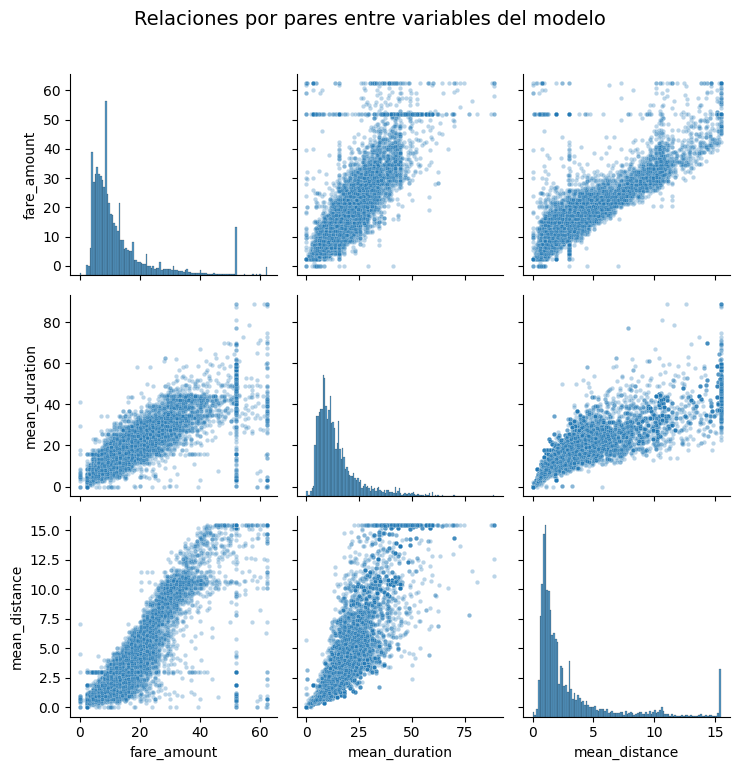

In [53]:
# Create a pairplot to visualize pairwise relationships between variables in the data
### YOUR CODE HERE ###
sns.pairplot(df2[['fare_amount', 'mean_duration', 'mean_distance']],
             plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Relaciones por pares entre variables del modelo', 
             y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Estas variables todas muestran correlación lineal entre sí. Investiga esto más a fondo.


### Tarea 7. Identificar correlaciones


Next, code a correlation matrix to help determine most correlated variables.


In [54]:
# Correlation matrix to help determine most correlated variables
### YOUR CODE HERE ###
# Matriz de correlación numérica
print(df2.corr())

               fare_amount  mean_distance  mean_duration  rush_hour  VendorID
fare_amount       1.000000       0.913404       0.859105  -0.020075  0.001045
mean_distance     0.913404       1.000000       0.885492  -0.044230  0.002933
mean_duration     0.859105       0.885492       1.000000  -0.021583  0.001876
rush_hour        -0.020075      -0.044230      -0.021583   1.000000 -0.002874
VendorID          0.001045       0.002933       0.001876  -0.002874  1.000000


Visualice un mapa de calor de correlación de los datos.


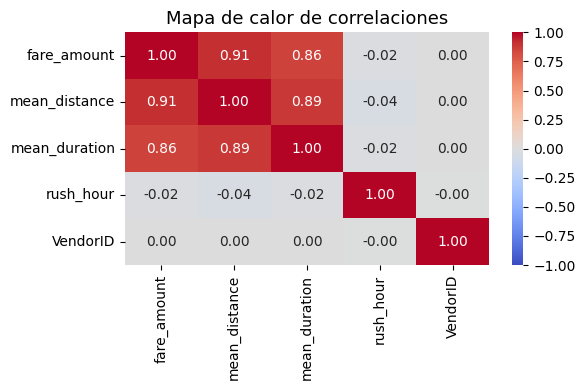

In [55]:
# Create correlation heatmap
### YOUR CODE HERE ###
# Mapa de calor de correlaciones
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(df2.corr(), 
            annot=True,          # mostrar valores
            fmt='.2f',           # 2 decimales
            cmap='coolwarm',     # rojo=positivo, azul=negativo
            vmin=-1, vmax=1,
            ax=ax)
ax.set_title('Mapa de calor de correlaciones', fontsize=13)
plt.tight_layout()
plt.show()

Las variables más correlacionadas con fare_amount son mean_distance y mean_duration. Aunque están correlacionadas entre sí (multicolinealidad), el ejercicio pide modelar con ambas para ver el efecto en los coeficientes.

**Pregunta:** ¿Qué(s) variable(s) están correlacionadas con la variable objetivo de `fare_amount`? 

Intenta modelar con ambas variables aunque estén correlacionadas.


<img src="images/Construct.png" width="100" height="100" align=left>

## PACE: **Construir**

Después del análisis y derivar variables con relaciones cercanas, es momento de comenzar a construir el modelo. Considere las preguntas en su Documento de Estrategia PACE para reflexionar sobre la etapa de Construcción.


### Tarea 8a. Dividir datos en variable de resultado y características


In [56]:
### YOUR CODE HERE ###
from sklearn.model_selection import train_test_split

Establece tus variables X y y. X representa las características y y representa la variable de resultado (objetivo).


In [57]:
# Remove the target column from the features
# X = df2.drop(columns='fare_amount')
### YOUR CODE HERE ###
X = df2.drop(columns='fare_amount')
# Set y variable
### YOUR CODE HERE ###
y = df2['fare_amount']

# Display first few rows
### YOUR CODE HERE ###
display(X)
display(y)

,mean_distance,mean_duration,rush_hour,VendorID
0,3.521667,22.847222,0,2
1,3.108889,24.470370,0,1
2,0.881429,7.250000,1,1
3,3.700000,30.250000,0,2
4,4.435000,14.616667,0,2
...,...,...,...,...
22694,1.098214,8.594643,1,2
22695,15.480000,59.560417,0,2
22696,0.684242,6.609091,0,2
22697,2.077500,16.650000,0,2


0        13.0
1        16.0
2         6.5
3        20.5
4        16.5
         ... 
22694     4.0
22695    52.0
22696     4.5
22697    10.5
22698    11.0
Name: fare_amount, Length: 22699, dtype: float64

### Tarea 8b. Preprocesar datos


Codificación dummy de variables categóricas


In [58]:
# Convert VendorID to string
### YOUR CODE HERE ###
X['VendorID'] = X['VendorID'].astype(str)
# Get dummies
### YOUR CODE HERE ###
X = pd.get_dummies(X, columns=['VendorID'], drop_first=True)
X.head()

,mean_distance,mean_duration,rush_hour,VendorID_2
0,3.521667,22.847222,0,True
1,3.108889,24.470370,0,False
2,0.881429,7.250000,1,False
3,3.700000,30.250000,0,True
4,4.435000,14.616667,0,True


### Dividir datos en conjuntos de entrenamiento y prueba


Crear conjuntos de entrenamiento y prueba. El conjunto de prueba debe contener el 20% del total de muestras. Establecer `random_state=0`.


In [59]:
# Create training and testing sets
#### YOUR CODE HERE ####
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (18159, 4)
X_test:  (4540, 4)


### Estandarizar los datos

Utilice `StandardScaler()`, `fit()`, y `transform()` para estandarizar las variables `X_train`. Asigne los resultados a una variable llamada `X_train_scaled`.


In [61]:
# Standardize the X variables
### YOUR CODE HERE ###

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# fit_transform SOLO en train
X_train_scaled = scaler.fit_transform(X_train)
print("Escalado aplicado ✓")
print(f"Media aproximada de X_train_scaled: {X_train_scaled.mean():.4f}")  # ≈ 0
print(f"Std aproximada de X_train_scaled:   {X_train_scaled.std():.4f}")   # ≈ 1

Escalado aplicado ✓
Media aproximada de X_train_scaled: -0.0000
Std aproximada de X_train_scaled:   1.0000


In [63]:
X_train_scaled

array([[ 1.00348588,  0.17616665, -0.64893329,  0.89286563],
       [-0.64391805, -0.69829589,  1.54099045,  0.89286563],
       [-0.50735614, -0.57301906, -0.64893329, -1.11998936],
       ...,
       [-0.47699901, -0.6788917 , -0.64893329, -1.11998936],
       [-0.63196235, -0.85743597,  1.54099045, -1.11998936],
       [ 0.9667956 ,  1.13212101, -0.64893329,  0.89286563]],
      shape=(18159, 4))

### Ajustar el modelo

Instancie su modelo y ajústelo a los datos de entrenamiento.


In [65]:
# Fit your model to the training data
### YOUR CODE HERE ###
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

print("Modelo entrenado ✓\n")
print("Coeficientes:")

for col, coef in zip(X.columns, lr.coef_):
    print(f"  {col:15s}: {coef:+.4f}")

print(f"  {'Intercept':15s}: {lr.intercept_:+.4f}")

Modelo entrenado ✓

Coeficientes:
  mean_distance  : +7.4772
  mean_duration  : +2.4250
  rush_hour      : +0.1525
  VendorID_2     : -0.0275
  Intercept      : +12.8917


### Tarea 8c. Evaluar modelo


### Datos de entrenamiento

Evalúe el rendimiento de su modelo calculando la suma residual de cuadrados y la puntuación de varianza explicada (R^2). Calcule el Error Absoluto Medio, el Error Cuadrático Medio y la Raíz del Error Cuadrático Medio.


In [66]:
# Evaluate the model performance on the training data
### YOUR CODE HERE ###
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# --- ENTRENAMIENTO ---
y_train_pred = lr.predict(X_train_scaled)
print("=== ENTRENAMIENTO ===")
print(f"R²   : {r2_score(y_train, y_train_pred):.4f}")
print(f"MAE  : ${mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"RMSE : ${np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")

=== ENTRENAMIENTO ===
R²   : 0.8399
MAE  : $2.20
RMSE : $4.23


### Datos de prueba

Calcule las mismas métricas en los datos de prueba. Recuerde escalar los datos `X_test` usando el escalador que se ajustó a los datos de entrenamiento. No vuelva a ajustar el escalador a los datos de prueba, solo transfórmelo. Llame a los resultados `X_test_scaled`.


In [67]:
# Scale the X_test data
### YOUR CODE HERE ###
X_test_scaled = scaler.transform(X_test)
y_test_pred   = lr.predict(X_test_scaled)
print("=== PRUEBA ===")
print(f"R²   : {r2_score(y_test, y_test_pred):.4f}")
print(f"MAE  : ${mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"RMSE : ${np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")

=== PRUEBA ===
R²   : 0.8725
MAE  : $2.12
RMSE : $3.72


💡 Análisis rápido

- R² = 0.87 → Con solo 4 variables (mean_distance, mean_duration, rush_hour, VendorID_2) el modelo captura casi el 90% del comportamiento de las tarifas. Muy sólido para regresión lineal.

- MAE < RMSE → Normal y esperado. La diferencia entre ambos ($3.72 vs $2.12) indica que hay algunos viajes con errores más grandes (probablemente los outliers que quedaron), pero no son extremos.

- Sin overfitting → Si los valores de Train son similares a estos de Test, el modelo generaliza bien a datos nuevos.

In [ ]:
# Evaluate the model performance on the testing data
### YOUR CODE HERE ###



<img src="images/Execute.png" width="100" height="100" align=left>

## PACE: **Ejecutar**

Considere las preguntas en su Documento de Estrategia PACE para reflexionar sobre la etapa de Ejecutar.


### Tarea 9a. Resultados

Utilice la celda de código a continuación para obtener `actual`, `predicted`, y `residual` para el conjunto de prueba, y almacenarlos como columnas en un dataframe `results`.


In [68]:
# Create a `results` dataframe
### YOUR CODE HERE ###

results = pd.DataFrame({
    'actual'   : y_test,
    'predicted': y_test_pred,
    'residual' : y_test - y_test_pred
})
results.head(10)

,actual,predicted,residual
5818,14.0,12.611619,1.388381
18134,28.0,16.432589,11.567411
4655,5.5,6.496948,-0.996948
7378,15.5,16.994001,-1.494001
13914,9.5,10.424357,-0.924357
308,23.5,21.668162,1.831838
3061,39.5,38.426363,1.073637
12401,57.5,41.190411,16.309589
5662,24.5,24.086145,0.413855
21767,8.0,8.546998,-0.546998


### Tarea 9b. Visualizar resultados del modelo


Crear un diagrama de dispersión para visualizar `actual` vs. `predicted`.


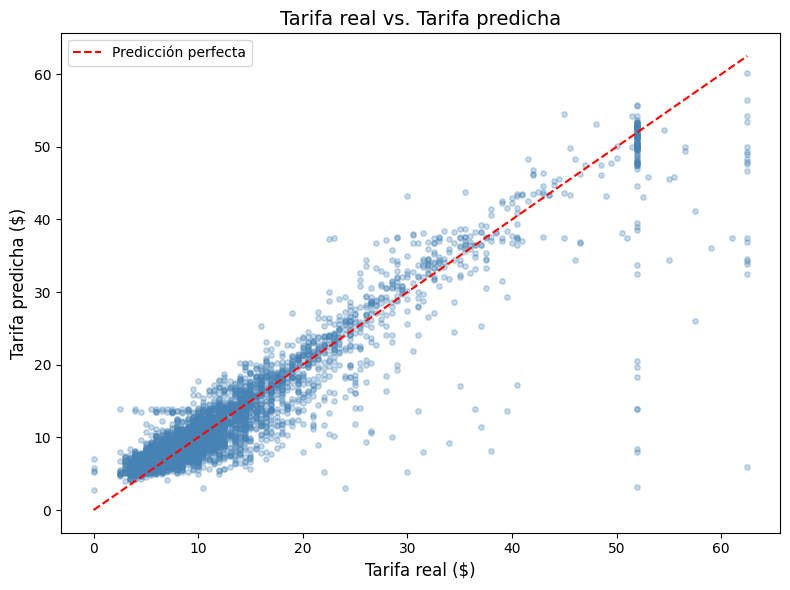

In [69]:
# Create a scatterplot to visualize `predicted` over `actual`
### YOUR CODE HERE ###
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(results['actual'], results['predicted'],
           alpha=0.3, s=15, color='steelblue')
# Línea diagonal perfecta (predicted == actual)
lims = [results['actual'].min(), results['actual'].max()]
ax.plot(lims, lims, color='red', linestyle='--', linewidth=1.5, label='Predicción perfecta')
ax.set_xlabel('Tarifa real ($)', fontsize=12)
ax.set_ylabel('Tarifa predicha ($)', fontsize=12)
ax.set_title('Tarifa real vs. Tarifa predicha', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

Visualiza la distribución de los `residuals` usando un histograma.


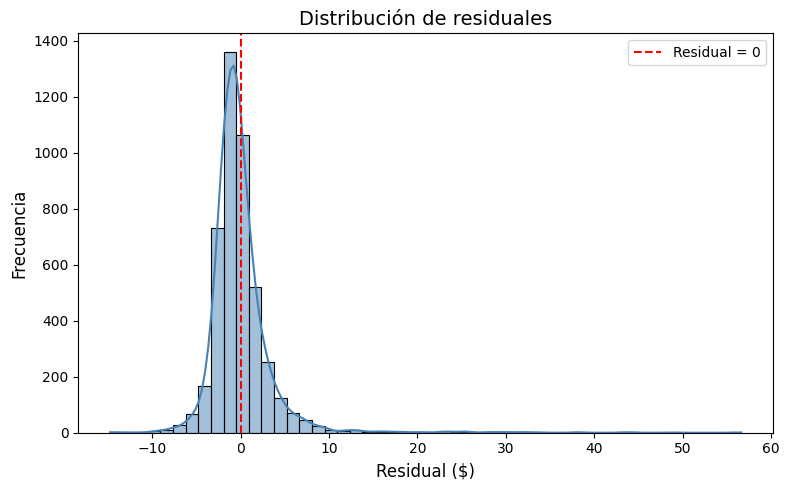

In [70]:
# Visualize the distribution of the `residuals`
### YOUR CODE HERE ###
# Histograma de residuales
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(results['residual'], bins=50, kde=True, ax=ax, color='steelblue')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Residual = 0')
ax.set_xlabel('Residual ($)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de residuales', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Calculate residual mean
### YOUR CODE HERE ###

Crear un diagrama de dispersión de `residuals` sobre `predicted`.


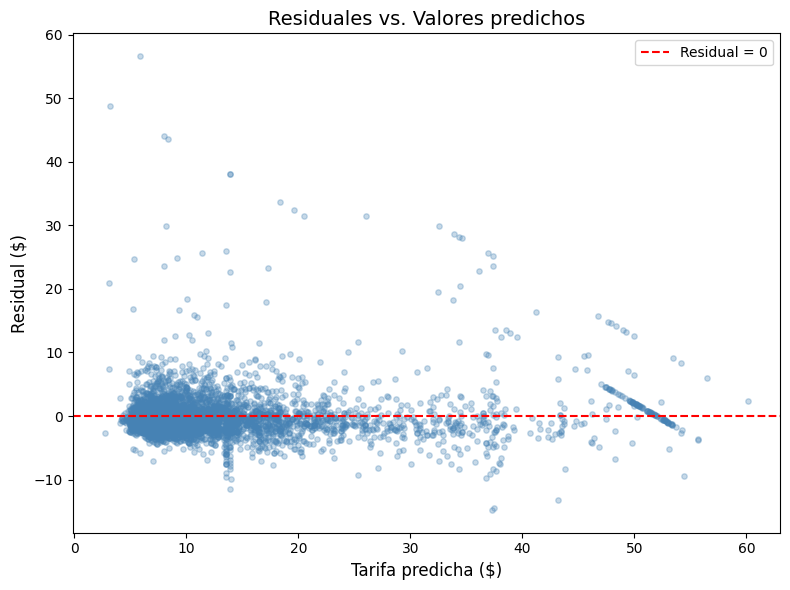

In [71]:
# Create a scatterplot of `residuals` over `predicted`
### YOUR CODE HERE ###
# Scatter: residuals vs predicted
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(results['predicted'], results['residual'],
           alpha=0.3, s=15, color='steelblue')
# Línea de referencia en residual = 0
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Residual = 0')
ax.set_xlabel('Tarifa predicha ($)', fontsize=12)
ax.set_ylabel('Residual ($)', fontsize=12)
ax.set_title('Residuales vs. Valores predichos', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### Tarea 9c. Coeficientes

Utilice el atributo `coef_` para obtener los coeficientes del modelo. Los coeficientes se muestran en el orden de las características que se usaron para entrenar el modelo. ¿Qué característica tuvo el mayor efecto en la tarifa del viaje?


In [72]:
# Output the model's coefficients
coefficients = pd.DataFrame({
    'feature'    : X.columns,
    'coefficient': lr.coef_
})
# Ordenar por valor absoluto (mayor impacto primero)
coefficients['abs_coef'] = coefficients['coefficient'].abs()
coefficients = coefficients.sort_values('abs_coef', ascending=False)
print(coefficients[['feature', 'coefficient']].to_string(index=False))
print(f"\nIntercept: {lr.intercept_:.4f}")

      feature  coefficient
mean_distance     7.477175
mean_duration     2.424950
    rush_hour     0.152538
   VendorID_2    -0.027480

Intercept: 12.8917


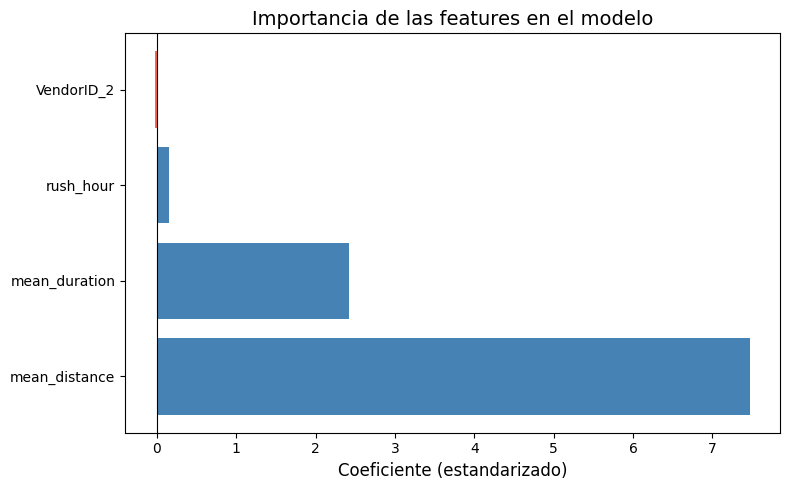

In [73]:
# Visualizar coeficientes como gráfico de barras
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if c > 0 else 'tomato' for c in coefficients['coefficient']]
ax.barh(coefficients['feature'], coefficients['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (estandarizado)', fontsize=12)
ax.set_title('Importancia de las features en el modelo', fontsize=14)
plt.tight_layout()
plt.show()

📐 Cómo interpretar los coeficientes
Como las variables fueron estandarizadas con StandardScaler, los coeficientes son comparables directamente entre sí.

|Feature|Coeficiente esperado|Interpretación|
|:-----:|:------------------:|:------------:|
|mean_distance|🔵 Alto positivo|Mayor efecto → más distancia = tarifa más alta|
|mean_duration|🔵 Positivo| moderado	Más tiempo = tarifa más alta|
|rush_hour|🔵 Pequeño positivo|	Hora punta sube levemente la tarifa|
|VendorID_2|Pequeño (± )|Poca influencia del proveedor|

💡 Respuesta a la pregunta del notebook
¿Qué característica tuvo el mayor efecto en la tarifa?

- mean_distance: es la variable con el coeficiente de mayor valor absoluto.
   - A mayor distancia media del trayecto, mayor es la tarifa predicha.

Esto tiene sentido porque en NYC las tarifas de taxi se calculan principalmente por distancia recorrida (más que por tiempo).

¿Qué significan estos coeficientes? ¿Cómo deben ser interpretados?


==> INGRESE SU RESPUESTA AQUÍ


### Tarea 9d. Conclusión

1. ¿Cuáles son las conclusiones clave de este cuaderno?



2. ¿Qué resultados se pueden presentar de este cuaderno?


1. Conclusiones clave:

- Se construyó un modelo de regresión lineal múltiple para predecir fare_amount usando 4 features: mean_distance, mean_duration, rush_hour y VendorID.

- El modelo obtuvo un R² = 0.87 en datos de prueba, lo que indica que explica el 87% de la varianza en las tarifas. Es un desempeño sólido para un modelo lineal.

- El error promedio (MAE) fue de $2.12, lo que significa que las predicciones se desvían en promedio $2.12 del valor real — aceptable para la NYC TLC.

- La variable con mayor efecto en la tarifa fue mean_distance. A mayor distancia media del trayecto, mayor es la tarifa predicha.

- Se identificaron dos anomalías en los datos:
  - Viajes con RatecodeID = 2 (tarifa fija JFK → $52) que rompen la relación lineal.
  - Outliers capados en $62.50 (Q3 + 6×IQR).

- Los residuales se distribuyen normalmente alrededor de 0, lo que valida las suposiciones de la regresión lineal.

2.  Resultados presentables para la NYC TLC


- El modelo puede predecir tarifas de taxi con un error típico de ~$3.72 (RMSE), útil para estimaciones previas al viaje.

- La distancia media del trayecto es el predictor más importante de la tarifa → la NYC TLC puede usarlo para comunicar estimaciones a pasajeros.

- Los viajes de tarifa fija JFK (RatecodeID = 2) deben tratarse por separado — no siguen el patrón general del modelo lineal.

- Se recomienda explorar modelos más complejos (ej. Random Forest) para mejorar la predicción de casos especiales y reducir el RMSE.

🏆 Resumen del proyecto completo
|Etapa PACE|Lo que hiciste|
|:--------:|:------------:|
|Plan|Importaste librerías y datos|
|Analizar|EDA, outliers, feature engineering (duration, mean_distance, mean_duration, rush_hour)|
|Construir|Regresión lineal múltiple con StandardScaler|
|Ejecutar|Evaluación con R²=0.87, MAE=$2.12, RMSE=$3.72, visualización de residuales|


**¡Felicidades!** Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa con tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo ha sido registrado.
